In [1]:
import fastf1
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

from dotenv import load_dotenv
import os
import requests
load_dotenv()

API_KEY = os.getenv("API_KEY")

In [2]:
fastf1.Cache.enable_cache("f1_cache")

In [3]:
# Weather Data from Shanghai GP
lat, lon = 31.2304, 121.4737

url_from_var = f"http://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
url_hardcoded = "http://api.openweathermap.org/data/2.5/forecast?lat=31.2304&lon=121.4737&appid=4d1aa06b0b99730fac4176f4cfa00256&units=metric"

print(repr(url_from_var))
print(repr(url_hardcoded))
print(url_from_var == url_hardcoded)

'http://api.openweathermap.org/data/2.5/forecast?lat=31.2304&lon=121.4737&appid=4d1aa06b0b99730fac4176f4cfa00256&units=metric'
'http://api.openweathermap.org/data/2.5/forecast?lat=31.2304&lon=121.4737&appid=4d1aa06b0b99730fac4176f4cfa00256&units=metric'
True


In [4]:
# load the 2026 China session data
session_china_2026 = fastf1.get_session(2026, "China", "Q")
session_china_2026.load()
laps_2026 = session_china_2026.laps[["Driver", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]].copy()
laps_2026.dropna(inplace=True)

# convert lap and sector times to seconds
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    laps_2026[f"{col} (s)"] = laps_2026[col].dt.total_seconds()

# aggregate sector times by driver
sector_times_2026 = laps_2026.groupby("Driver").agg({
    "Sector1Time (s)": "mean",
    "Sector2Time (s)": "mean",
    "Sector3Time (s)": "mean"
}).reset_index()

sector_times_2026["TotalSectorTime (s)"] = (
    sector_times_2026["Sector1Time (s)"] +
    sector_times_2026["Sector2Time (s)"] +
    sector_times_2026["Sector3Time (s)"]
)

# clean air race pace from racepace.py
clean_air_race_pace = {
    "VER": 93.191067, "HAM": 94.020622, "LEC": 93.418667, "NOR": 93.428600, "ALO": 94.784333,
    "PIA": 93.232111, "RUS": 93.833378, "SAI": 94.497444, "STR": 95.318250, "HUL": 95.345455,
    "OCO": 95.682128, "GAS": 95.987500, "ALB": 95.876000, "COL": 96.123333, "LAW": 96.456667,
    "LIN": 96.789000, "BOR": 97.234000, "HAD": 94.567000, "BEA": 97.890000, "PER": 98.678000,
    "ANT": 99.345000, "BOT": 98.901000
}

# quali data from China GP
qualifying_2026 = pd.DataFrame({
    "Driver": ["ANT", "RUS", "HAM", "LEC", "PIA", "NOR", "GAS", "VER", "HAD", "BEA", "HUL", "COL", "OCO", "LAW", "LIN", "BOR", "SAI", "ALB", "ALO", "BOT", "STR", "PER"],
    "QualifyingTime (s)": [
        92.064,  # ANT
        92.286,  # RUS
        92.415,  # HAM
        92.428,  # LEC
        92.550,  # PIA
        92.608,  # NOR
        92.873,  # GAS
        93.002,  # VER
        93.121,  # HAD
        93.292,  # BEA
        93.354,  # HUL
        93.357,  # COL
        93.538,  # OCO
        93.765,  # LAW
        93.784,  # LIN
        93.965,  # BOR
        94.317,  # SAI
        94.772,  # ALB
        95.203,  # ALO
        95.436,  # BOT
        95.995,  # STR
        96.906,  # PER
    ]
})


qualifying_2026["CleanAirRacePace (s)"] = qualifying_2026["Driver"].map(clean_air_race_pace)
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()

forecast_time = "2026-03-15 15:00:00"
forecast_data = next((f for f in weather_data["list"] if f["dt_txt"] == forecast_time), None)


rain_probability = forecast_data["pop"] if forecast_data else 0
temperature = forecast_data["main"]["temp"] if forecast_data else 20

# adjust qualifying time based on weather conditions
if rain_probability >= 0.75:
    qualifying_2026["QualifyingTime"] = qualifying_2026["QualifyingTime (s)"] * qualifying_2026["WetPerformanceFactor"]
else:
    qualifying_2026["QualifyingTime"] = qualifying_2026["QualifyingTime (s)"]

# add constructor's data
team_points = {
    "Mercedes": 43, "Ferrari": 27, "McLaren": 10, "Red Bull": 8, "Haas": 6, "Racing Bulls": 4,
    "Audi": 2, "Alpine": 1, "Williams": 0, "Cadillac": 0, "Aston Martin": 0
}

max_points = max(team_points.values())
team_performance_score = {team: points / max_points for team, points in team_points.items()}

driver_to_team = {
    "VER": "Red Bull", "HAD": "Red Bull", "NOR": "McLaren", "PIA": "McLaren", "LEC": "Ferrari", "HAM": "Ferrari",
    "RUS": "Mercedes", "ANT": "Mercedes", "GAS": "Alpine", "COL": "Alpine", "ALO": "Aston Martin", "STR": "Aston Martin",
    "SAI": "Williams", "ALB": "Williams", "HUL": "Audi", "BOR": "Audi", "BEA": "Haas", "OCO": "Haas",
    "BOT": "Cadillac", "PER": "Cadillac", "LAW": "Racing Bulls", "LIN": "Racing Bulls"
}

qualifying_2026["Team"] = qualifying_2026["Driver"].map(driver_to_team)
qualifying_2026["TeamPerformanceScore"] = qualifying_2026["Team"].map(team_performance_score)

# merge qualifying and sector times data
merged_data = qualifying_2026.merge(sector_times_2026[["Driver", "TotalSectorTime (s)"]], on="Driver", how="left")
merged_data["RainProbability"] = rain_probability
merged_data["Temperature"] = temperature
merged_data["QualifyingTime"] = merged_data["QualifyingTime"]


valid_drivers = merged_data["Driver"].isin(laps_2026["Driver"].unique())
merged_data = merged_data[valid_drivers]


core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
logger      WARNING 	Failed to load telemetry data!
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']

   Driver  PredictedRaceTime (s)
0     ANT             106.773582
1     RUS             107.413414
2     HAM             107.413414
3     LEC             107.413414
4     NOR             107.413414
5     HAD             107.413414
6     BEA             108.003029
7     COL             108.003029
8     LAW             108.003029
9     LIN             108.003029
10    GAS             108.163155
11    PIA             108.185028
12    VER             108.185028
13    BOT             108.615379
14    PER             108.645386
15    OCO             109.210236
16    HUL             109.317055
17    BOR             113.229027
18    SAI             113.389153
19    ALB             113.389153
20    ALO             113.389153
21    STR             114.444183

🏆 Predicted in the Top 3 🏆
🥇 P1: ANT
🥈 P2: RUS
🥉 P3: HAM
Model Error (MAE): 0.79 seconds


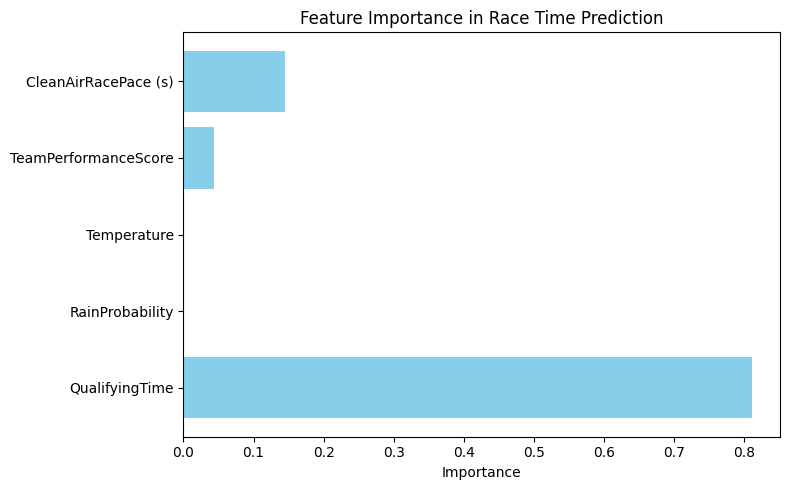

In [5]:
# define features (X) and target (y)
X = merged_data[[
    "QualifyingTime", "RainProbability", "Temperature", "TeamPerformanceScore", 
    "CleanAirRacePace (s)"
]]
y = laps_2026.groupby("Driver")["LapTime (s)"].mean().reindex(merged_data["Driver"])

# impute missing values for features
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.1, random_state=39)

# train XGBoost model
model = XGBRegressor(n_estimators=300, learning_rate=0.9, max_depth=3, random_state=39,  monotone_constraints='(1, 0, 0, -1, -1)')
model.fit(X_train, y_train)
merged_data["PredictedRaceTime (s)"] = model.predict(X_imputed)

# sort the results to find the predicted winner
final_results = merged_data.sort_values(by=["PredictedRaceTime (s)", "QualifyingTime"]).reset_index(drop=True)
print(final_results[["Driver", "PredictedRaceTime (s)"]])

# sort results and get top 3
podium = final_results.loc[:7, ["Driver", "PredictedRaceTime (s)"]]
print("\n🏆 Predicted in the Top 3 🏆")
print(f"🥇 P1: {podium.iloc[0]['Driver']}")
print(f"🥈 P2: {podium.iloc[1]['Driver']}")
print(f"🥉 P3: {podium.iloc[2]['Driver']}")
y_pred = model.predict(X_test)
print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")

# Plot feature importances
feature_importance = model.feature_importances_
features = X.columns 

plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance in Race Time Prediction")
plt.tight_layout()
plt.show()